# CHEESE API — kind cluster demo

Connect to the minimal `cheese` stack running on the local **kind** cluster and exercise the CHEESE API (search over the on-prem databases).

**Prereqs:** the cluster is up (`k8s/kind-up.local.sh`) and healthy (`kubectl -n cheese get pods`).

**How this connects:** the chart exposes the orchestrator via an nginx ingress with host `cheese-api.localtest.me`, and kind maps it to host port 80. We send requests to `http://localhost` with a `Host:` header — the most reliable path on this box. If you prefer a direct URL or have no ingress, see the *Connectivity* section at the bottom (port-forward).

Uses only the Python standard library (`urllib`); `pandas`/`rdkit` are used automatically **if** installed, but nothing here requires them.

In [1]:
import json, urllib.request, urllib.parse

# --- connection config -------------------------------------------------------
BASE_URL = "http://localhost"                 # kind maps host :80 -> ingress
HOST_HEADER = "cheese-api.localtest.me"       # ingress rule host
TIMEOUT = 120                                  # searches can take a while

print("configured:", BASE_URL, "(Host:", HOST_HEADER + ")")

configured: http://localhost (Host: cheese-api.localtest.me)


## 1. Connectivity + health

In [2]:
def cheese(path, **params):
    """GET {BASE_URL}{path}?params with the ingress Host header. Returns parsed JSON (or text)."""
    qs = ("?" + urllib.parse.urlencode(params, doseq=True)) if params else ""
    req = urllib.request.Request(BASE_URL + path + qs, headers={"Host": HOST_HEADER})
    with urllib.request.urlopen(req, timeout=TIMEOUT) as r:
        body = r.read().decode()
    try:
        return json.loads(body)
    except json.JSONDecodeError:
        return body

In [3]:
print("health   :", cheese("/health"))
# Full OpenAPI surface (endpoint count + the search-related paths)
spec = cheese("/openapi.json")
paths = sorted(spec["paths"])
print("endpoints:", len(paths))
print("search    :", [p for p in paths if "search" in p])
print("types     :", spec["components"]["schemas"]["SearchTypes"]["enum"])

health   : OK
endpoints: 37
search    : ['/batch_search', '/get_molsearch_page', '/molsearch', '/molsearch_array', '/molsearch_embedding', '/molsearch_simple', '/search_file', '/submit_molsearch']
types     : ['morgan', 'espsim_electrostatic', 'espsim_shape', 'synthongpt']


## 2. Available databases

Which databases the running stack serves, and how many molecules each holds.

In [4]:
dbs = cheese("/available_databases")
DB_NAMES = list(dbs)
try:
    import pandas as pd
    display(pd.DataFrame(dbs).T)
except ImportError:
    for name, meta in dbs.items():
        print(f"{name:16} {meta.get('Number of molecules'):>12,}  {meta.get('Vendor','')}")
print("\nDB_NAMES =", DB_NAMES)

,Vendor,Website,Email,Number of molecules,backend_kind,count_source
ENAMINE-AA,Enamine,https://enamine.net,info@enamine.net,373812,enumerative,numlines.txt
MCULE-IN-STOCK,Mcule,https://mcule.com/,order@mcule.com,5943962,enumerative,numlines.txt
ZINC15,N/A,https://zinc15.docking.org/,N/A,697119304,enumerative,numlines.txt



DB_NAMES = ['ENAMINE-AA', 'MCULE-IN-STOCK', 'ZINC15']


## 3. Similarity search

`/molsearch_simple` takes a query SMILES and returns nearest neighbours. `search_type` is one of the CHEESE API search types:

| search_type | meaning |
|---|---|
| `morgan` | 2D structural (Morgan / Tanimoto) |
| `espsim_electrostatic` | 3D electrostatic similarity |
| `espsim_shape` | 3D shape similarity |

In [5]:
def search(smiles, search_type="morgan", db_names=None, n=5):
    """Run a similarity search and return a list of {smiles, id, database} dicts."""
    db_names = db_names or (DB_NAMES[0] if DB_NAMES else "")
    res = cheese("/molsearch_simple",
                 search_input=smiles, search_type=search_type,
                 db_names=db_names, n_neighbors=n)
    # response is columnar: {"smiles":[...], "id":[...], "database":[...]}
    keys = [k for k in res if isinstance(res[k], list)]
    rows = [dict(zip(keys, vals)) for vals in zip(*(res[k] for k in keys))]
    return rows

ASPIRIN = "CC(=O)Oc1ccccc1C(=O)O"
hits = search(ASPIRIN, "morgan", n=5)
for h in hits:
    print(h["database"], h["id"], h["smiles"])

ENAMINE-AA s_240690____16943638____7418186-DMCH CN(C)CCOc1ccccc1C(=O)Nc1cccc(CC(N)C(=O)O)c1
ENAMINE-AA s_240690____16745514____7418186-DMCH CN(C)CCOc1ccccc1C(=O)Nc1cccc(C[C@H](N)C(=O)O)c1
ENAMINE-AA s_272430____26328902____26418138-DMCH CC(C)(C)Oc1ccccc1C(=O)Nc1cccc(CC(N)C(=O)O)c1
ENAMINE-AA s_240690____16745510____10874030-DMCH Cc1cccc(Oc2ccccc2C(=O)Nc2ccc(C[C@H](N)C(=O)O)cc2)c1
ENAMINE-AA s_240690____20080410____10874030-DMCH Cc1cccc(Oc2ccccc2C(=O)Nc2ccc(C[C@@H](N)C(=O)O)cc2)c1


### Compare all three search types on the same query

In [6]:
for st in ("morgan", "espsim_electrostatic", "espsim_shape"):
    top = search(ASPIRIN, st, n=1)
    print(f"{st:22} -> {top[0]['smiles'] if top else '(none)'}")

morgan                 -> CN(C)CCOc1ccccc1C(=O)Nc1cccc(C[C@H](N)C(=O)O)c1
espsim_electrostatic   -> N[C@H](CC(=O)Nc1cccc(F)c1C(=O)C(F)(F)F)C(=O)O
espsim_shape           -> CC(=O)c1ccccc1N(C)C(=O)C[C@@H](N)C(=O)O


### Optional: draw the hits (needs `rdkit`)

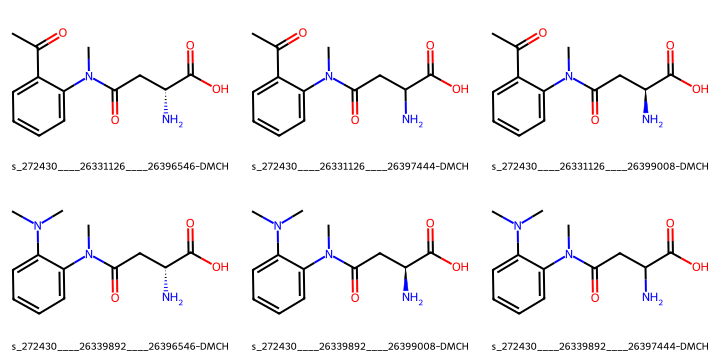

In [7]:
try:
    from rdkit import Chem
    from rdkit.Chem import Draw
    hits = search(ASPIRIN, "espsim_shape", n=6)
    mols = [Chem.MolFromSmiles(h["smiles"]) for h in hits]
    display(Draw.MolsToGridImage(mols, legends=[h["id"] for h in hits], molsPerRow=3, subImgSize=(240, 180)))
except ImportError:
    print("rdkit not installed — skip drawing (pip install rdkit)")

## 4. Search across multiple databases at once

`db_names` accepts several DBs (repeat the param); results are merged.

In [8]:
rows = search(ASPIRIN, "morgan", db_names=DB_NAMES, n=3)
for r in rows:
    print(f"{r['database']:16} {r['smiles']}")

MCULE-IN-STOCK   CC(=O)Oc1ccccc1C(=O)O
ZINC15           CC(=O)Oc1ccccc1C(=O)[O-]
ZINC15           CC(=O)Oc1ccccc1C(=O)Oc1ccc(F)cc1


## Connectivity notes

**Default (used above):** requests go to `http://localhost` with header `Host: cheese-api.localtest.me`. kind's `extraPortMappings` bind host `:80` to the ingress controller.

**Alternative — no ingress / port-forward.** Skip the ingress and talk to the orchestrator Service directly:

```bash
kubectl -n cheese port-forward svc/cheese-orchestrator 8080:80
```

then set at the top of this notebook:

```python
BASE_URL = "http://localhost:8080"
HOST_HEADER = "localhost"   # Host header no longer matters
```

**Interactive API docs:** open <http://cheese-api.localtest.me/docs> in a browser (FastAPI Swagger UI).